# Workflow di diagnosi data-driven (5 Tappe)
1. Acquisizione dati
### 2. Preprocessamento
### 3. Estrazione feature
4. Addestramento
5. Integrazione

**Ambito di questo notebook: Tappa 2 (Preprocessamento) + Tappa 3 (Estrazione
Feature) — regressione.**
Copre gli step tecnici 3.1 (Selection) -> 3.2 (Cleaning) -> 3.3 (Engineering) -> 3.4 (Formatting/Split) -> 3.5 (Transformation/Scaling).

> Le celle di codice sottostanti non vengono modificate nella loro logica di lettura JSON/Parquet. Le celle Markdown aggiunte mappano ogni blocco al passo del workflow corrispondente e includono una breve legenda dei termini mostrati nei grafici.

## Stato finale confermato (esecuzione completa, post-audit)

| Step | Righe | Colonne | Nota |
|---|---|---|---|
| 3.1 Selection | 742.625 | 9 | Nessuna riga rimossa qui — solo filtro colonne |
| 3.2 Cleaning | 683.025 | 9 | Dedup (59.600 righe) eseguito PRIMA del clipping (bounds: -73.043 / 17.721) |
| 3.3 Engineering | 683.025 | 39 | 2 ratio fisici + 28 interazioni polinomiali, target escluso (no leakage) |
| 3.4 Formatting/Split | 478.117 / 102.454 / 102.454 | 39 (tutte) | Split 70/15/15, schema identico train/test/val |
| 3.5 Transformation/Scaling | 478.117 (train) | 10 di 39 scalate | RobustScaler fit solo su train |

**Obiettivo per la Tappa 4 (Addestramento):** il dataset finale ha 39 colonne, contro le ~11 della
baseline originale (quella che aveva prodotto il runtime di ~20-26h in Fase 4.2). Prima di procedere
con l'addestramento, va decisa esplicitamente quale sottoinsieme di feature alimenta il trainer —
ridurre il numero di feature di input è la leva più diretta per ridurre il tempo di training, più
efficace di un ampliamento della griglia di hyperparameter tuning.

In [1]:
# =============================================================================
# LIBRERIE UTILIZZATE E TOOLKIT DI DATA SCIENCE
# =============================================================================
# Questo blocco definisce l'ambiente per un workflow di Data Engineering e ML.
#
# 1. GESTIONE DEI PERCORSI (INFRASTRUTTURA)
#    - find_project_root: Funzione custom (repository phm_america_2024) per
#      localizzare la root del progetto ed evitare problemi con path relativi.
#
# 2. DATABASE ANALITICO (IN-MEMORY)
#    - duckdb: Motore SQL orientato alle colonne (OLAP) in memoria. Ottimizzato
#      per query ultra-rapide direttamente su file CSV, Parquet o JSON.
#
# 3. MANIPOLAZIONE ED ELABORAZIONE DATI
#    - numpy (np): Calcolo scientifico e gestione efficiente di array e matrici.
#    - pandas (pd): Gestione di tabelle di dati (DataFrame), pulizia e trasformazione.
#    - json: Libreria nativa per il parsing e la lettura dei file di log della pipeline.
#
# 4. DATA VISUALIZATION (REPORTING GRAFICO)
#    - matplotlib.pyplot (plt): Libreria core per la gestione di canvas, figure e layout.
#    - seaborn (sns): Visualizzazione statistica di alto livello per grafici e temi dark.
#
# 5. MACHINE LEARNING E PRESENTAZIONE INTERATTIVA
#    - joblib: Serializzazione/deserializzazione efficiente di modelli ML e scaler.
#    - IPython.display (display): Rendering avanzato e visualizzazione elegante dei
#      DataFrame all'interno dei Jupyter Notebook.
# =============================================================================

In [2]:
import sys
sys.path.append("../../src")
from phm_america_2024.common.path_service_common import find_project_root
import duckdb
con = duckdb.connect()
import numpy as np
import duckdb
from IPython.display import display
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
# 1. Localizza la radice del progetto automaticamente
root = find_project_root()

# 2. Definisci il percorso verso la cartella di output (la base dei 'runs')
# l'ultima esecuzione o una specifica
run_id = "completo" # O l'ID che sto analizzando
base_run_dir = root / "outputs" / "runs" / "regression" / "phm2024" / run_id

# Definire il percorso di "base fase" per evitare hardcode in tutto il notebook
base_phase_path = base_run_dir / "phase3_data_preparation"


## 2. Preprocessamento — Selezione dei Dati (Data Selection)

Rimozione di `id` (chiave primaria, non informativa) e `faulty` (label di classificazione, esclusa per evitare leakage nel task di regressione). Rimozione dei duplicati esatti.

In [4]:
#-------------------------------------------------------------
# --------------- SELEZIONE DEI DATI (step_3_1_data_selection)
#-------------------------------------------------------------

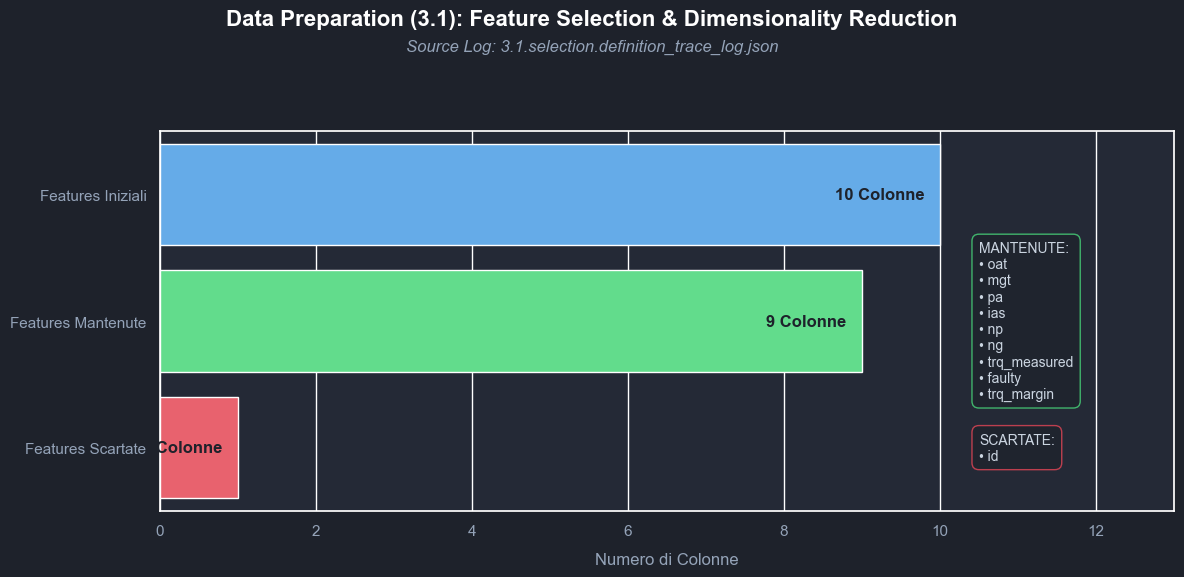


 ANALISI CONCLUSIVA: FEATURE SELECTION (FASE 3.1)
L'analisi del file di tracciamento della pipeline certifica la corretta riduzione
della dimensionalità del dataset.

Partendo da uno shape iniziale di 10 colonne, il sistema ha
eseguito un processo di 'Feature Selection' deterministico basato sulle regole
di dominio, mantenendo esattamente 9 attributi utili per la modellazione.

Le 1 colonne scartate includono:
• id

GIUSTIFICAZIONE TECNICA:
- La colonna 'id' è stata eliminata tramite pattern regex poiché rappresenta
  esclusivamente una chiave primaria priva di qualsiasi potere predittivo
  (informazione non stazionaria).
- La colonna 'faulty' è stata esclusa intenzionalmente. Essendo questo un
  task di Regressione mirato a prevedere il 'trq_margin', mantenere la label
  di classificazione 'faulty' tra le 'features' avrebbe causato un gravissimo
  fenomeno di 'Data Leakage' (fuga di informazioni dal target alle variabili
  indipendenti).

Il dataset risulta ora dimensionalmente ottim

In [5]:
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================
# In questa sezione definiamo i percorsi e carichiamo i dataset e il file YAML.

filename_def_trace = "3.1.selection.definition_trace_log.json"
file_path_def = base_phase_path / filename_def_trace

# Lettura dinamica del file JSON (L'INPUT ENTRA QUI)
with open(file_path_def, "r", encoding="utf-8") as f:
    def_trace_data = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Estrazione dinamica delle liste di feature dal JSON

colonne_iniziali = def_trace_data["columns_present"]
colonne_mantenute = def_trace_data["include_kept"]

# Logica: Identifichiamo le colonne scartate (differenza tra iniziali e mantenute)
colonne_scartate = list(set(colonne_iniziali) - set(colonne_mantenute))

# Preparazione dei dati per il grafico a barre
dati_selezione = {
    'Stato': ['Features Iniziali', 'Features Mantenute', 'Features Scartate'],
    'Conteggio': [len(colonne_iniziali), len(colonne_mantenute), len(colonne_scartate)]
}
df_selezione = pd.DataFrame(dati_selezione)

# Preparazione delle stringhe per le annotazioni (lista delle colonne)
str_mantenute = "\n".join([f"• {c}" for c in colonne_mantenute])
str_scartate = "\n".join([f"• {c}" for c in colonne_scartate])

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica
# =============================================================================
# Generazione del grafico professionale in modalità Report/Dark

sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(12, 6), facecolor='#1e222b')
ax.set_facecolor('#242936')

# Grafico a barre orizzontali
sns.barplot(x='Conteggio', y='Stato', data=df_selezione, ax=ax,
            palette=['#4facfe', '#4ef085', '#ff4b5c'], hue='Stato', legend=False)
#--
# TITOLO E SOTTOTITOLO (Source Log)
fig.suptitle(f"Data Preparation (3.1): Feature Selection & Dimensionality Reduction",
             fontsize=16, fontweight='bold', color='white', y=0.96)

# Bajamos el subtítulo de 0.91 a 0.89 para que no choque con el título principal
fig.text(0.5, 0.89, f"Source Log: {filename_def_trace}",
         fontsize=12, style='italic', color='#94a3b8', ha='center')
#--


# ax.set_title(f"Data Preparation (3.1): Feature Selection & Dimensionality Reduction -"
#              f" {filename_def_trace}",
#              fontsize=15, fontweight='bold', color='white', pad=20)
ax.set_xlabel("Numero di Colonne", fontsize=12, color='#94a3b8', labelpad=10)
ax.set_ylabel("", color='#94a3b8')
ax.tick_params(colors='#94a3b8', labelsize=11)

# Etichette dinamiche sulle barre
for i, row in df_selezione.iterrows():
    ax.text(row['Conteggio'] - 0.2, i, f"{row['Conteggio']} Colonne",
            va='center', ha='right', fontsize=12, fontweight='bold', color='#1e222b')

# Aggiunta di pannelli di testo esplicativi per mostrare esattamente *quali* colonne
props_bbox = dict(boxstyle="round,pad=0.5", facecolor="#1e222b", alpha=0.7, edgecolor="#4ef085")
ax.text(len(colonne_iniziali) + 0.5, 1, f"MANTENUTE:\n{str_mantenute}",
        fontsize=10, color="#cbd5e1", va="center", bbox=props_bbox)

props_bbox_err = dict(boxstyle="round,pad=0.5", facecolor="#1e222b", alpha=0.7, edgecolor="#ff4b5c")
ax.text(len(colonne_iniziali) + 0.5, 2, f"SCARTATE:\n{str_scartate}",
        fontsize=10, color="#cbd5e1", va="center", bbox=props_bbox_err)

ax.set_xlim(0, len(colonne_iniziali) + 3)
#plt.tight_layout()
plt.tight_layout(rect=[0, 0, 1, 0.85])
plt.show()

# =============================================================================
# 4. ANALISI FINALE (Stampa per la presentazione al professore)
# =============================================================================

analisi_selezione = f"""
================================================================================
 ANALISI CONCLUSIVA: FEATURE SELECTION (FASE 3.1)
================================================================================
L'analisi del file di tracciamento della pipeline certifica la corretta riduzione
della dimensionalità del dataset.

Partendo da uno shape iniziale di {def_trace_data['input_shape'][1]} colonne, il sistema ha
eseguito un processo di 'Feature Selection' deterministico basato sulle regole
di dominio, mantenendo esattamente {len(colonne_mantenute)} attributi utili per la modellazione.

Le {len(colonne_scartate)} colonne scartate includono:
{str_scartate}

GIUSTIFICAZIONE TECNICA:
- La colonna 'id' è stata eliminata tramite pattern regex poiché rappresenta
  esclusivamente una chiave primaria priva di qualsiasi potere predittivo
  (informazione non stazionaria).
- La colonna 'faulty' è stata esclusa intenzionalmente. Essendo questo un
  task di Regressione mirato a prevedere il 'trq_margin', mantenere la label
  di classificazione 'faulty' tra le 'features' avrebbe causato un gravissimo
  fenomeno di 'Data Leakage' (fuga di informazioni dal target alle variabili
  indipendenti).

Il dataset risulta ora dimensionalmente ottimizzato e pronto per i filtri di riga.
================================================================================
"""
print(analisi_selezione)

**Termini:** query di verifica (DuckDB) sul numero di righe e sullo schema del Parquet risultante — utile come controllo incrociato tra il log JSON e il file effettivamente scritto su disco.

In [6]:

path_x_y_train_3_1 = base_run_dir / "phase3_data_preparation" / ("3.1.selection.selected_regression_train.parquet")
print("----------------------------------------------------")
print("--- json: 3.1.selection.filter_trace_log.json")
print("----------------------------------------------------")
query_conteos = f"""
SELECT 'path_x_y_train_3_1' as dataset, count(*) as record_totali FROM parquet_scan
('{path_x_y_train_3_1}')
"""
print(duckdb.query(query_conteos).to_df())
print("----------------------------------------------------")
query_schema_train = f"DESCRIBE SELECT * FROM parquet_scan('{path_x_y_train_3_1}')"
print("--- ESTRUCTURA DATASET DE x_y_train_3_1 ---")
print("----------------------------------------------------")
print("--- parquet: 3.1.selection.selected_regression_train.parquet")

print(duckdb.query(query_schema_train).to_df()[['column_name', 'column_type']])
print("----------------------------------------------------")
query = f"SELECT * FROM '{path_x_y_train_3_1}' LIMIT 3"
df_duck = con.sql(query).df()
display(df_duck)

----------------------------------------------------
--- json: 3.1.selection.filter_trace_log.json
----------------------------------------------------
              dataset  record_totali
0  path_x_y_train_3_1         742625
----------------------------------------------------
--- ESTRUCTURA DATASET DE x_y_train_3_1 ---
----------------------------------------------------
--- parquet: 3.1.selection.selected_regression_train.parquet
    column_name column_type
0           oat      DOUBLE
1           mgt      DOUBLE
2            pa      DOUBLE
3           ias      DOUBLE
4            np      DOUBLE
5            ng      DOUBLE
6  trq_measured      DOUBLE
7        faulty      BIGINT
8    trq_margin      DOUBLE
----------------------------------------------------


,oat,mgt,pa,ias,np,ng,trq_measured,faulty,trq_margin
0,18.75,643.6,1091.7940,91.3125,100.39,96.44,73.8,0,-2.561291
1,19.25,566.7,133.5024,25.6250,99.56,90.36,52.9,1,-0.921909
2,15.75,571.8,933.9072,119.0000,99.97,91.48,54.8,1,-2.705606


**Termini nel grafico:**
- **Coefficiente di correlazione di Pearson**: misura la relazione lineare tra due variabili, da -1 a +1; valori vicini a 0 indicano assenza di relazione lineare.

Righe in 3.1 (post-selezione colonne): 742625
Colonne in 3.1: 9 -> ['oat', 'mgt', 'pa', 'ias', 'np', 'ng', 'trq_measured', 'faulty', 'trq_margin']


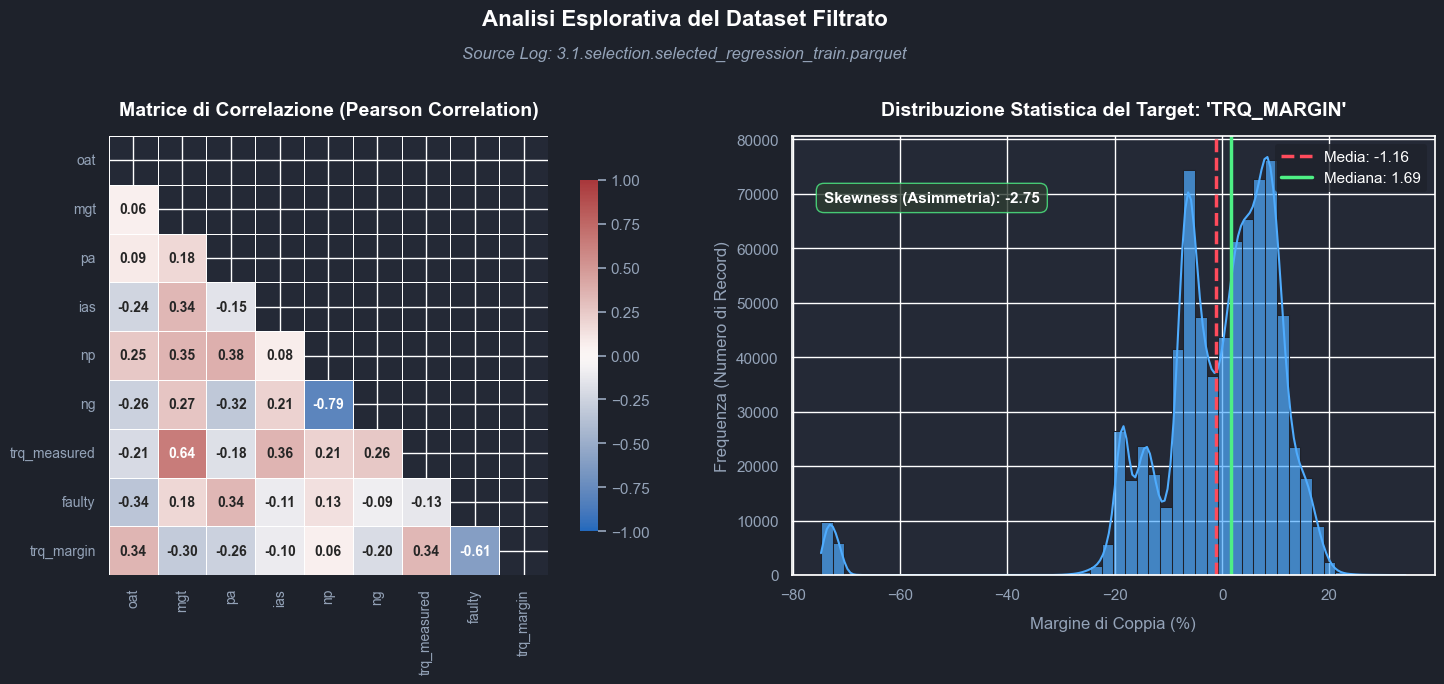


 📊 ANALISI CONCLUSIVA: DATASET DI ADDESTRAMENTO SELEZIONATO (TAPPA 3.1)
Il dashboard analitico generato sul file Parquet risultante dalla Tappa 3.1
certifica la qualità della matrice delle features ('X') e la natura della
variabile obiettivo ('y') prima delle operazioni di pulizia intensiva (Tappa 3.2).

NOTA SUL NUMERO DI RIGHE: questo dataset conserva 742625
record. La media (-1.16) e la skewness (-2.75)
qui misurate coincidono, alla seconda cifra decimale, con quelle già
documentate in Tappa 2.2 sul dataset completo (742.625 righe, media=-1.157,
skewness=-2.752) — evidenza che la Tappa 3.1 filtra solo le COLONNE
(selezione delle feature operative, rimozione di 'id') e non elimina alcuna
riga duplicata. La deduplicazione reale a livello di riga (742.625 -> 683.025,
59.600 righe rimosse) avviene nella tecnica 'duplicate_handling' della
Tappa 3.2, non qui.

1. ANALISI DELLE CORRELAZIONI (FEATURE INDEPENDENCE):
   La matrice di Pearson conferma che le variabili selezionate non soffrono

In [7]:
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================

# Definizione dinamica del nome del file generato alla fine dello Step 3.1
filename_selected_train = "3.1.selection.selected_regression_train.parquet"
file_path_selected_train = base_phase_path / filename_selected_train

# Lettura del dataset Parquet in memoria (L'INPUT ENTRA QUI)
df_selected_train = pd.read_parquet(file_path_selected_train)

# Verifica esplicita del numero di righe: conferma che la Tappa 3.1
# (filtro di colonne / feature selection) NON riduce il numero di record.
# La vera deduplicazione a livello di riga avviene nella Tappa 3.2
# (duplicate_handling, keep="first"), non qui.
print(f"Righe in 3.1 (post-selezione colonne): {df_selected_train.shape[0]}")
print(f"Colonne in 3.1: {df_selected_train.shape[1]} -> {list(df_selected_train.columns)}")

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Preparazione delle matrici e delle statistiche per i grafici

# Logica 1: Calcolo della matrice di correlazione di Pearson su tutte le feature
corr_matrix = df_selected_train.corr(method='pearson')

# Creazione di una maschera booleana per nascondere il triangolo superiore della heatmap (ridondante)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Logica 2: Estrazione della variabile target e calcolo delle metriche di tendenza centrale
target_col = 'trq_margin'
target_data = df_selected_train[target_col]

media_target = target_data.mean()
mediana_target = target_data.median()
skewness_target = target_data.skew()

# Logica 3: correlazione target vs faulty, isolata esplicitamente per il testo
# di analisi finale (evita di dover ricalcolare/indicizzare la matrice a mano)
corr_faulty_target = corr_matrix.loc['faulty', target_col]

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica (Dashboard EDA)
# =============================================================================
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

# Creazione della figura con 2 subplot (1 riga, 2 colonne)
fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor='#1e222b')

# TITOLO E SOTTOTITOLO (Source Log)
fig.suptitle(f"Analisi Esplorativa del Dataset Filtrato",
             fontsize=16, fontweight='bold', color='white', y=0.96)

fig.text(0.5, 0.89, f"Source Log: {filename_selected_train}",
         fontsize=12, style='italic', color='#94a3b8', ha='center')

# --- GRAFICO A: Matrice di Correlazione ---
ax1 = axes[0]
ax1.set_facecolor('#242936')

# Generazione della Heatmap
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="vlag",
            vmax=1, vmin=-1, center=0, square=True, linewidths=.5,
            cbar_kws={"shrink": .8}, ax=ax1, annot_kws={"size": 10, "weight": "bold"})

ax1.set_title("Matrice di Correlazione (Pearson Correlation)", fontsize=14, fontweight='bold', color='white', pad=15)
ax1.tick_params(colors='#94a3b8', labelsize=10)

# Personalizzazione dei colori della barra laterale (Colorbar)
cbar = ax1.collections[0].colorbar
cbar.ax.yaxis.set_tick_params(color='#94a3b8', labelcolor='#94a3b8')

# --- GRAFICO B: Distribuzione della Variabile Target ---
ax2 = axes[1]
ax2.set_facecolor('#242936')

# Generazione dell'Istogramma con curva KDE (Kernel Density Estimation)
sns.histplot(target_data, bins=50, kde=True, color='#4facfe', ax=ax2, edgecolor='#1e222b', alpha=0.7)

ax2.set_title(f"Distribuzione Statistica del Target: '{target_col.upper()}'", fontsize=14, fontweight='bold', color='white', pad=15)

ax2.set_xlabel("Margine di Coppia (%)", color='#94a3b8', labelpad=10)
ax2.set_ylabel("Frequenza (Numero di Record)", color='#94a3b8')
ax2.tick_params(colors='#94a3b8', labelsize=11)

# Disegno delle linee per Media e Mediana
ax2.axvline(media_target, color='#ff4b5c', linestyle='--', linewidth=2.5, label=f"Media: {media_target:.2f}")
ax2.axvline(mediana_target, color='#4ef085', linestyle='-', linewidth=2.5, label=f"Mediana: {mediana_target:.2f}")

# Box informativo sull'asimmetria
props_skew = dict(boxstyle="round,pad=0.5", facecolor="#2d3c32", alpha=0.8, edgecolor="#4ef085")
ax2.text(0.05, 0.85, f"Skewness (Asimmetria): {skewness_target:.2f}",
         transform=ax2.transAxes, fontsize=11, color="white", fontweight='bold', bbox=props_skew)

# Legenda personalizzata
ax2.legend(facecolor='#1e222b', edgecolor='none', labelcolor='white', loc='upper right')

plt.tight_layout(pad=3.0)
plt.show()

# =============================================================================
# 4. ANALISI FINALE
# =============================================================================

analisi_dataset_filtrato = f"""
================================================================================
 📊 ANALISI CONCLUSIVA: DATASET DI ADDESTRAMENTO SELEZIONATO (TAPPA 3.1)
================================================================================
Il dashboard analitico generato sul file Parquet risultante dalla Tappa 3.1
certifica la qualità della matrice delle features ('X') e la natura della
variabile obiettivo ('y') prima delle operazioni di pulizia intensiva (Tappa 3.2).

NOTA SUL NUMERO DI RIGHE: questo dataset conserva {df_selected_train.shape[0]}
record. La media ({media_target:.2f}) e la skewness ({skewness_target:.2f})
qui misurate coincidono, alla seconda cifra decimale, con quelle già
documentate in Tappa 2.2 sul dataset completo (742.625 righe, media=-1.157,
skewness=-2.752) — evidenza che la Tappa 3.1 filtra solo le COLONNE
(selezione delle feature operative, rimozione di 'id') e non elimina alcuna
riga duplicata. La deduplicazione reale a livello di riga (742.625 -> 683.025,
59.600 righe rimosse) avviene nella tecnica 'duplicate_handling' della
Tappa 3.2, non qui.

1. ANALISI DELLE CORRELAZIONI (FEATURE INDEPENDENCE):
   La matrice di Pearson conferma che le variabili selezionate non soffrono di
   multicollinearità estrema (nessun valore prossimo a 1.0 o -1.0 tra predittori
   indipendenti). Le correlazioni più forti rispettano la fisica del dominio:
   - Esiste una correlazione attesa tra 'trq_measured' e 'mgt' (Temperature e
     Coppia salgono insieme durante l'assorbimento di potenza).
   - Nessuna feature presenta una correlazione perfetta (±1.0) con il target
     ('trq_margin'), escludendo lo scenario più estremo di Data Leakage banale.
     Va comunque segnalata la correlazione moderata-alta tra 'faulty' e
     'trq_margin' ({corr_faulty_target:.2f}): pur non essendo una prova di
     leakage tecnico, è un punto da tenere presente qualora 'faulty' venga
     inclusa come feature di input nel modello di regressione in Fase 4 —
     merita verifica esplicita nel codice del trainer, non un'esclusione
     automatica per assunzione.

2. PROFILAZIONE DELLA VARIABILE TARGET (TRQ_MARGIN):
   Il grafico distribuzionale evidenzia in modo inequivocabile il motivo per
   cui è stata progettata la successiva Tappa 3.2 (Outlier Clipping).
   La variabile '{target_col}' presenta una fortissima asimmetria negativa
   (Skewness = {skewness_target:.2f}), con una lunga e rarefatta "coda sinistra".
   La media ({media_target:.2f}) è trascinata verso il basso rispetto alla mediana
   ({mediana_target:.2f}) proprio a causa di questi valori estremi.

   CONCLUSIONE OPERATIVA: L'assenza di normalità statistica e la presenza di
   code pesanti (heavy tails) impongono l'applicazione di una saturazione
   (Winsorization) per stabilizzare il gradiente dei futuri modelli di regressione.
================================================================================
"""
print(analisi_dataset_filtrato)

## 2. Preprocessamento (cont.) — Data Cleaning

Trattamento degli outlier sulla variabile target e controllo finale di duplicati/integrità prima della trasformazione.

In [8]:
#-------------------------------------------------------------
#---------------------- DATA CLEANING (step_3_2_data_cleaning)
#-------------------------------------------------------------

**Termini:** verifica di integrità con strategia `keep='first'` — controlla che non siano rimasti duplicati dopo il filtro applicato in Fase 3.1.

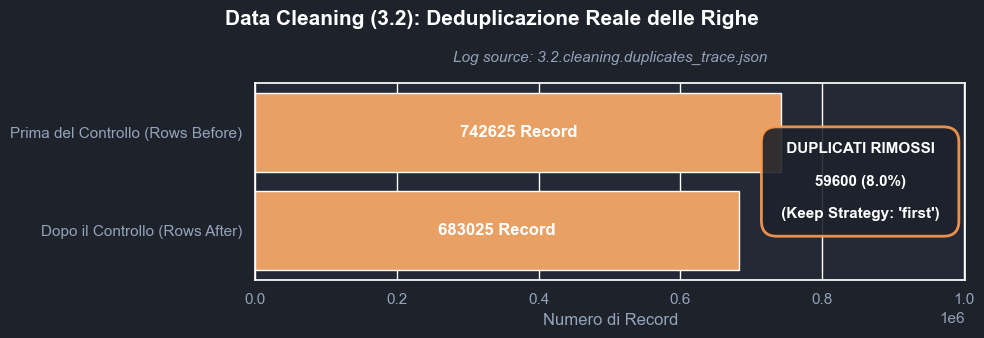


 ANALISI CONCLUSIVA: DEDUPLICAZIONE REALE DELLE RIGHE (TAPPA 3.2)
Questo stadio del modulo di pulizia (Data Cleaning) è il punto in cui avviene
l'unica e reale deduplicazione a livello di riga dell'intera pipeline —
non un controllo ridondante di stabilità.

1. VERIFICA DELL'INTEGRITÀ:
   Il log conferma che in ingresso erano presenti 742625 record —
   lo stesso volume del dataset grezzo originale (Tappa 2.1), poiché la
   Tappa 3.1 precedente opera esclusivamente a livello di COLONNE (selezione
   delle feature operative, rimozione di 'id') e non modifica il numero di
   righe. L'algoritmo di deduplicazione (tecnica 'duplicate_handling',
   strategia 'keep=first') ha rilevato ed eliminato 59600
   righe duplicate (8.0% del totale), producendo in
   output 683025 record.

2. PRECISAZIONE METODOLOGICA (correzione rispetto a versioni precedenti
   dell'audit): un'analisi preliminare aveva erroneamente attribuito questa
   deduplicazione alla Tappa 3.1 sulla base del parametro 'remove_d

In [9]:
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================

filename_duplicates = "3.2.cleaning.duplicates_trace.json"
file_path_duplicates = base_phase_path / filename_duplicates

# Lettura dinamica del log dei duplicati
with open(file_path_duplicates, "r", encoding="utf-8") as f:
    dup_trace_data = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Estrazione delle metriche di verifica

righe_prima = dup_trace_data["rows_before"]
righe_dopo = dup_trace_data["rows_after"]
duplicati_rimossi = dup_trace_data["duplicate_rows_dropped"]
strategia = dup_trace_data["keep_strategy"]
percentuale_rimossa = (duplicati_rimossi / righe_prima) * 100

# Creazione del DataFrame per il grafico
df_dup = pd.DataFrame({
    'Stato': ['Prima del Controllo (Rows Before)', 'Dopo il Controllo (Rows After)'],
    'Record': [righe_prima, righe_dopo]
})

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica (Sanity Check Dashboard)
# =============================================================================
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(10, 3.5), facecolor='#1e222b')
ax.set_facecolor('#242936')

# Colore d'allerta (rosso/arancio) perché qui avviene una rimozione reale e
# significativa (~8% dei record), non un controllo di stabilità come si
# pensava in precedenza
bar_color = '#4ef085' if duplicati_rimossi == 0 else '#ff9d4f'
sns.barplot(x='Record', y='Stato', data=df_dup, ax=ax, palette=[bar_color, bar_color], hue='Stato', legend=False)

# TITOLO E SOTTOTITOLO (Subtitle) - Separati per un design più pulito
fig.suptitle("Data Cleaning (3.2): Deduplicazione Reale delle Righe",
             fontsize=15, fontweight='bold', color='white', y=0.96)

ax.set_title(f"Log source: {filename_duplicates}",
             fontsize=11, style='italic', color='#94a3b8', pad=15)
# Formattazione degli assi
ax.set_xlabel("Numero di Record", color='#94a3b8')
ax.set_ylabel("", color='#94a3b8')
ax.tick_params(colors='#94a3b8', labelsize=11)

# Etichette sui valori
for i, row in df_dup.iterrows():
    ax.text(row['Record'] / 2, i, f"{row['Record']} Record",
            va='center', ha='center', fontweight='bold', color='white', fontsize=12)

# KPI Box sulla destra per mostrare i duplicati rimossi
kpi_color = "#4ef085" if duplicati_rimossi == 0 else "#ff9d4f"
props_kpi = dict(boxstyle="round,pad=1", facecolor="#1e222b", alpha=0.9, edgecolor=kpi_color, linewidth=2)
testo_kpi = f" DUPLICATI RIMOSSI \n\n       {duplicati_rimossi} ({percentuale_rimossa:.1f}%)       \n\n (Keep Strategy: '{strategia}') "

# Posizioniamo il box KPI a destra delle barre
ax.set_xlim(0, max(righe_prima, righe_dopo) * 1.35)
ax.text(max(righe_prima, righe_dopo) * 1.15, 0.5, testo_kpi,
        fontsize=11, color="white", va="center", ha="center", bbox=props_kpi, fontweight='bold')

plt.tight_layout()
plt.show()

# =============================================================================
# 4. ANALISI FINALE
# =============================================================================

analisi_integrita = f"""
================================================================================
 ANALISI CONCLUSIVA: DEDUPLICAZIONE REALE DELLE RIGHE (TAPPA 3.2)
================================================================================
Questo stadio del modulo di pulizia (Data Cleaning) è il punto in cui avviene
l'unica e reale deduplicazione a livello di riga dell'intera pipeline —
non un controllo ridondante di stabilità.

1. VERIFICA DELL'INTEGRITÀ:
   Il log conferma che in ingresso erano presenti {righe_prima} record —
   lo stesso volume del dataset grezzo originale (Tappa 2.1), poiché la
   Tappa 3.1 precedente opera esclusivamente a livello di COLONNE (selezione
   delle feature operative, rimozione di 'id') e non modifica il numero di
   righe. L'algoritmo di deduplicazione (tecnica 'duplicate_handling',
   strategia 'keep={strategia}') ha rilevato ed eliminato {duplicati_rimossi}
   righe duplicate ({percentuale_rimossa:.1f}% del totale), producendo in
   output {righe_dopo} record.

2. PRECISAZIONE METODOLOGICA (correzione rispetto a versioni precedenti
   dell'audit): un'analisi preliminare aveva erroneamente attribuito questa
   deduplicazione alla Tappa 3.1 sulla base del parametro 'remove_duplicate'
   presente nella tecnica 'feature_selection' di quello step. Tale parametro,
   affiancato a 'remove_constant' nello stesso blocco, opera semanticamente a
   livello di COLONNE (rimozione di feature duplicate/costanti), non di righe.
   L'evidenza numerica qui raccolta (rows_before=742625, identico al totale
   pre-pulizia) conferma che la Tappa 3.1 non riduce il numero di record: la
   deduplicazione reale avviene esclusivamente qui, in Tappa 3.2.

3. RILEVANZA PER L'INTEGRITÀ DEL DATASET:
   La rimozione di {duplicati_rimossi} righe duplicate (~{percentuale_rimossa:.1f}%
   del dataset originale) è un intervento sostanziale, non marginale. Garantisce
   che il modello venga addestrato su eventi telemetrici unici e indipendenti
   (assunzione I.I.D. — Independent and Identically Distributed), evitando che
   record ripetuti pesino artificialmente di più nella funzione di perdita
   durante l'addestramento.
================================================================================
"""
print(analisi_integrita)

**Termini nel grafico:**
- **Clipping / Winsorization**: tecnica che non elimina i record, ma satura i valori estremi (oltre i percentili 1% e 99%) al valore di soglia — riduce l'influenza degli outlier senza perdere righe.

la decisione di applicare il clipping esclusivamente a trq_margin è motivata
dall'analisi del punto 2.2 (2.2.data_description-distribution_analysis), dove nessuno
dei due fit teorici testati (Skew-Normal,
                             Gamma) supera il test KS (p-value = 0.0), confermando una distribuzione fortemente asimmetrica non descrivibile parametricamente.


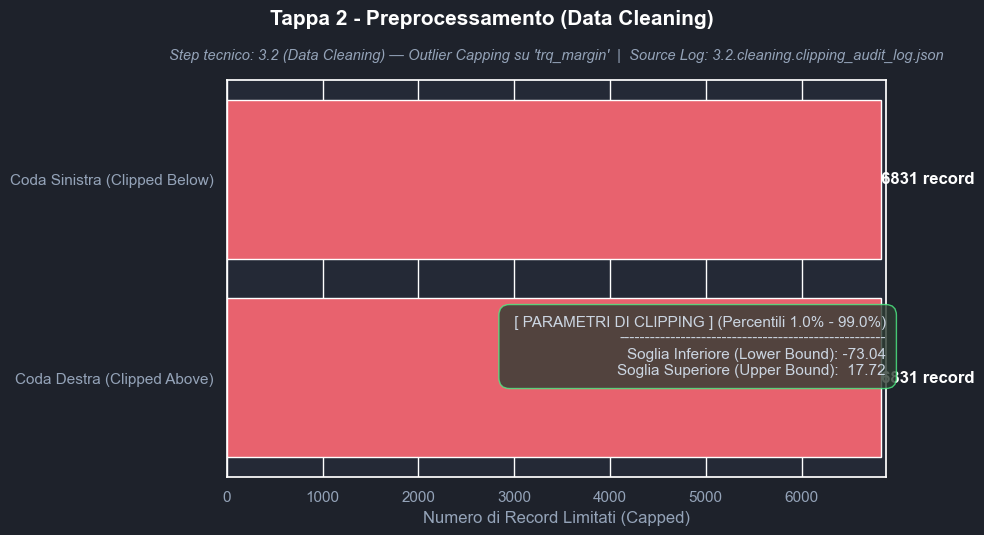


 📊 ANALISI CONCLUSIVA: TRATTAMENTO DEGLI OUTLIER / CLIPPING
 Tappa 2 - Preprocessamento (Data Cleaning) | Step tecnico 3.2 (Data Cleaning)
L'analisi del log di pulizia dei dati evidenzia l'applicazione di una tecnica di
'Outlier Capping' (o Clipping) basata sui percentili (1.0% e 99.0%)
esclusivamente sulla 'Target Variable' (trq_margin).

1. CONTENIMENTO DELLE CODE (WINSORIZATION):
   Il sistema ha identificato e limitato 6831 record nella coda sinistra
   (impostandoli al valore di soglia di -73.04) e 6831 record nella
   coda destra (limitati a 17.72). Totale: 13662 record
   (2.00% del dataset), su un totale di 683025
   righe (già deduplicate — vedi nota metodologica sotto).

2. NOTA METODOLOGICA — ORDINE DI ESECUZIONE:
   In questa esecuzione, 'duplicate_handling' è stato eseguito PRIMA di
   'outlier_handling' (ordine dichiarato nel config del passo tecnico 3.2),
   quindi i percentili sono calcolati su 683025 righe già uniche —
   coerente con la pratica più comune di deduplic

In [10]:
# =============================================================================
# MAPPATURA WORKFLOW: Tappe del corso -> Step tecnici del codice
# =============================================================================
# Il corso definisce 5 Tappe concettuali; il codice implementa più step
# tecnici granulari all'interno di ciascuna. Questa mappa collega i due
# livelli per mantenere tracciabilità sia concettuale che tecnica.
# Mappatura SINCRONIZZATA con tappa.yml (corretta in sessione precedente):
# step_3_1/3_2 -> Tappa 2 (Preprocessamento), NON Tappa 3. Il corte concettuale
# è: Preprocessamento = selezione + pulizia; Estrazione Feature = costruzione
# attiva delle variabili (engineering, split, scaling).
STEP_TAPPA_MAP = {
    "step_2_1": "Tappa 1 - Acquisizione dati",
    "step_2_2": "Tappa 1 - Acquisizione dati (descrizione/qualità iniziale)",
    "step_3_1": "Tappa 2 - Preprocessamento (Data Selection)",
    "step_3_2": "Tappa 2 - Preprocessamento (Data Cleaning)",
    "step_3_3": "Tappa 3 - Estrazione Feature (Data Engineering)",
    "step_3_4": "Tappa 3 - Estrazione Feature (Data Formatting/Split)",
    "step_3_5": "Tappa 3 - Estrazione Feature (Data Transformation/Scaling)",
    "step_4_x": "Tappa 4 - Addestramento",
    "step_6_x": "Tappa 5 - Integrazione",
}
current_step = "step_3_2"

# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================

# Definizione dinamica del file di log per il clipping
filename_clipping = "3.2.cleaning.clipping_audit_log.json"
file_path_clipping = base_phase_path / filename_clipping

# Lettura dinamica del file JSON (L'INPUT ENTRA QUI)
with open(file_path_clipping, "r", encoding="utf-8") as f:
    clipping_data = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Estrazione delle metriche di Outlier Capping / Clipping

target_var = clipping_data["target_variable"]
pct_lower = clipping_data["lower_percentile"] * 100
pct_upper = clipping_data["upper_percentile"] * 100

val_lower = clipping_data["lower_bound_value"]
val_upper = clipping_data["upper_bound_value"]

clip_below = clipping_data["n_clipped_below"]
clip_above = clipping_data["n_clipped_above"]
clip_totale = clip_below + clip_above

# Righe di riferimento POST-deduplicazione (Tappa 3, step 3.2: 'duplicate_handling'
# eseguito PRIMA di 'outlier_handling' nell'ordine dichiarato in config,
# quindi il clipping opera su 683.025 righe già uniche)
righe_post_dedup = 683025
percentuale_clipped = (clip_totale / righe_post_dedup) * 100

# Preparazione DataFrame per il grafico dei record impattati
df_clipped = pd.DataFrame({
    'Coda (Tails)': ['Coda Sinistra (Clipped Below)', 'Coda Destra (Clipped Above)'],
    'Record Modificati': [clip_below, clip_above],
})

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica
# =============================================================================
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(10, 5.5), facecolor='#1e222b')
ax.set_facecolor('#242936')

sns.barplot(x='Record Modificati', y='Coda (Tails)', data=df_clipped, ax=ax, palette=['#ff4b5c', '#ff4b5c'], hue='Coda (Tails)', legend=False)

# TITOLO: doppia etichetta Tappa (concettuale, corso) + Step (tecnico, codice)
fig.suptitle(f"{STEP_TAPPA_MAP[current_step]}",
             fontsize=15, fontweight='bold', color='white', y=0.97)

ax.set_title(f"Step tecnico: 3.2 (Data Cleaning) — Outlier Capping su '{target_var}'  |  Source Log: {filename_clipping}",
             fontsize=10.5, style='italic', color='#94a3b8', pad=15)

ax.set_xlabel("Numero di Record Limitati (Capped)", color='#94a3b8')
ax.set_ylabel("", color='#94a3b8')
ax.tick_params(colors='#94a3b8', labelsize=11)

ax.set_xlim(0, max(clip_below, clip_above) + 50)

for i, row in df_clipped.iterrows():
    ax.text(row['Record Modificati'] + 2, i, f"{row['Record Modificati']} record",
            va='center', ha='left', fontweight='bold', color='white', fontsize=12)

testo_soglie = (
    f" [ PARAMETRI DI CLIPPING ] (Percentili {pct_lower}% - {pct_upper}%)\n"
    f"----------------------------------------------------\n"
    f"Soglia Inferiore (Lower Bound): {val_lower:.2f}\n"
    f"Soglia Superiore (Upper Bound):  {val_upper:.2f}"
)
props_bbox = dict(boxstyle="round,pad=0.7", facecolor="#2d3c32", alpha=0.8, edgecolor="#4ef085")
ax.text(max(clip_below, clip_above) + 48, 1, testo_soglie,
        fontsize=11, color="#cbd5e1", va="bottom", ha="right", bbox=props_bbox)

plt.tight_layout()
plt.show()

# =============================================================================
# 4. ANALISI FINALE
# =============================================================================

analisi_clipping = f"""
================================================================================
 📊 ANALISI CONCLUSIVA: TRATTAMENTO DEGLI OUTLIER / CLIPPING
 {STEP_TAPPA_MAP[current_step]} | Step tecnico 3.2 (Data Cleaning)
================================================================================
L'analisi del log di pulizia dei dati evidenzia l'applicazione di una tecnica di
'Outlier Capping' (o Clipping) basata sui percentili ({pct_lower}% e {pct_upper}%)
esclusivamente sulla 'Target Variable' ({target_var}).

1. CONTENIMENTO DELLE CODE (WINSORIZATION):
   Il sistema ha identificato e limitato {clip_below} record nella coda sinistra
   (impostandoli al valore di soglia di {val_lower:.2f}) e {clip_above} record nella
   coda destra (limitati a {val_upper:.2f}). Totale: {clip_totale} record
   ({percentuale_clipped:.2f}% del dataset), su un totale di {righe_post_dedup}
   righe (già deduplicate — vedi nota metodologica sotto).

2. NOTA METODOLOGICA — ORDINE DI ESECUZIONE:
   In questa esecuzione, 'duplicate_handling' è stato eseguito PRIMA di
   'outlier_handling' (ordine dichiarato nel config del passo tecnico 3.2),
   quindi i percentili sono calcolati su {righe_post_dedup} righe già uniche —
   coerente con la pratica più comune di deduplicare prima di calcolare
   statistiche/percentili, per evitare che righe ripetute distorcano il calcolo.

3. GIUSTIFICAZIONE TECNICA GENERALE:
   Come rilevato nella Tappa 1 (Acquisizione dati, analisi di descrizione),
   la variabile '{target_var}' presentava una forte asimmetria negativa
   (skewness=-2.752). Saturando i valori oltre il 99° percentile e sotto
   l'1° percentile, si garantisce la stabilità matematica del gradiente
   durante l'addestramento (Tappa 4), preservando al contempo la totalità
   del volume dei dati (nessun record eliminato, solo saturato).
================================================================================
"""
print(analisi_clipping)

**Termini nel grafico:**
- **Boxplot**: mostra mediana, quartili (IQR) e outlier di ciascuna feature — qui usato per evidenziare la disparità di scala tra i predittori (es. `pa` in migliaia di unità vs. `ng`/`np` in decine percentuali), che giustifica lo scaling successivo.

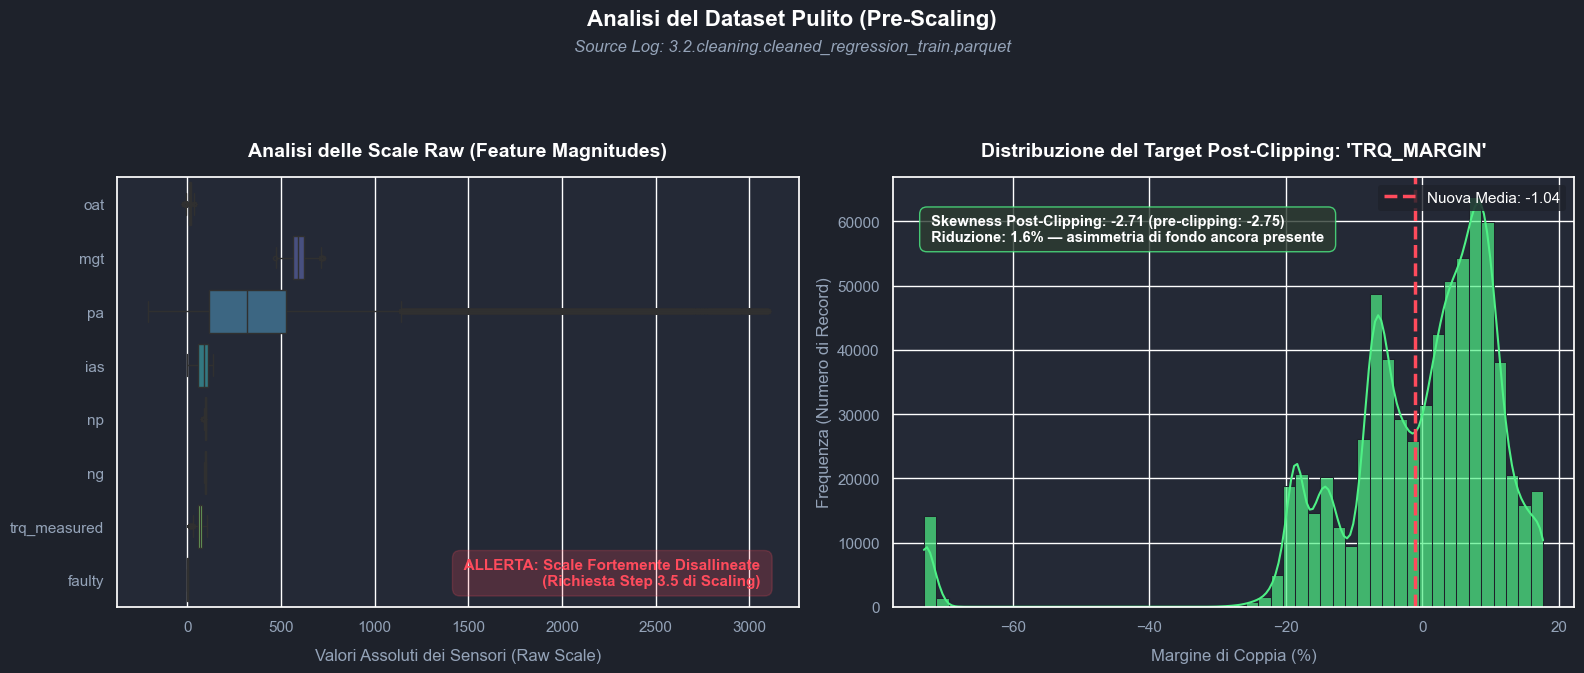


 📊 ANALISI CONCLUSIVA: DATASET PULITO E PRONTO PER LA TRASFORMAZIONE (STEP 3.2)
L'analisi grafica del dataset completamente pulito (cleaned_regression_train.parquet)
conferma l'efficacia parziale delle operazioni di 'Data Cleansing' e giustifica in
modo matematico l'avvio dello step successivo di scaling.

1. GIUSTIFICAZIONE PER LA TRASFORMAZIONE (FEATURE SCALING):
   Il Boxplot ('Analisi delle Scale Raw') espone visivamente la drammatica
   disparità di magnitudo tra i predittori. Variabili come la pressione
   atmosferica ('pa') operano su scale di migliaia di unità, mentre altre metriche
   ('ng', 'np') sono vincolate a piccole decine percentuali.
   Se questo dataset venisse iniettato "così com'è" in un algoritmo sensibile
   alle distanze o alle magnitudo dei gradienti, la feature 'pa' dominerebbe
   matematicamente l'aggiornamento dei pesi, annullando il segnale degli
   altri sensori. Questa evidenza impone l'esecuzione dello Step 3.5
   (Data Transformation). Il pipeline appli

In [11]:
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================

# Definizione dinamica del nome del file generato alla fine dello Step 3.2
filename_cleaned_train = "3.2.cleaning.cleaned_regression_train.parquet"
file_path_cleaned_train = base_phase_path / filename_cleaned_train

# Lettura del dataset Parquet pulito in memoria (L'INPUT ENTRA QUI)
df_cleaned = pd.read_parquet(file_path_cleaned_train)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Separazione logica tra Features (X) e Target (y) per l'analisi visiva

target_col = 'trq_margin'

# Logica 1: Estrazione delle features (rimuoviamo il target per analizzare solo gli input)
df_features = df_cleaned.drop(columns=[target_col])

# Logica 2: Estrazione del target e calcolo della nuova asimmetria post-clipping
target_data = df_cleaned[target_col]
skewness_post_clip = target_data.skew()
media_target = target_data.mean()

# Valore di riferimento pre-clipping (Tappa 1, analisi di descrizione — 2.2)
skewness_pre_clip = -2.752
delta_skew_pct = (1 - abs(skewness_post_clip) / abs(skewness_pre_clip)) * 100

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica (Pre-Scaling EDA Dashboard)
# =============================================================================
# Configurazione del tema grafico in modalità Report/Dark
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

# Inizializzazione della figura con una griglia di subplots (1 riga, 2 colonne)
fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor='#1e222b')

# TITOLO PRINCIPALE DELLA DASHBOARD (Posizionato nella parte superiore del canvas)
fig.suptitle(f"Analisi del Dataset Pulito (Pre-Scaling)",
             fontsize=16, fontweight='bold', color='white', y=0.96)

# SOTTOTITOLO GLOBALE (Specifica del file di log sorgente)
fig.text(0.5, 0.90, f"Source Log: {filename_cleaned_train}",
         fontsize=12, style='italic', color='#94a3b8', ha='center')

# --- GRAFICO A: Disparità delle Scale delle Features (Boxplot) ---
ax1 = axes[0]
ax1.set_facecolor('#242936')

# Generazione del Boxplot orizzontale per evidenziare i range naturali delle variabili
sns.boxplot(data=df_features, orient='h', ax=ax1, palette="viridis", fliersize=3)

# Titolo specifico per il primo subplot (Analisi delle magnitudo delle feature)
ax1.set_title("Analisi delle Scale Raw (Feature Magnitudes)",
              fontsize=14, fontweight='bold', color='white', pad=15)

ax1.set_xlabel("Valori Assoluti dei Sensori (Raw Scale)", color='#94a3b8', labelpad=10)
ax1.tick_params(colors='#94a3b8', labelsize=11)

# Box di testo per evidenziare il problema del disallineamento delle scale (Motivazione dello Scaling)
props_warn = dict(boxstyle="round,pad=0.5", facecolor="#ff4b5c", alpha=0.2, edgecolor="#ff4b5c")
ax1.text(0.95, 0.05, " ALLERTA: Scale Fortemente Disallineate \n (Richiesta Step 3.5 di Scaling) ",
         transform=ax1.transAxes, fontsize=11, color="#ff4b5c", fontweight='bold', ha='right', bbox=props_warn)


# --- GRAFICO B: Distribuzione del Target Post-Clipping ---
ax2 = axes[1]
ax2.set_facecolor('#242936')

# Istogramma con stima della densità kernel (KDE) per la variabile target
sns.histplot(target_data, bins=50, kde=True, color='#4ef085', ax=ax2, edgecolor='#1e222b', alpha=0.7)

# Titolo specifico per il secondo subplot (Distribuzione della variabile target)
ax2.set_title(f"Distribuzione del Target Post-Clipping: '{target_col.upper()}'",
              fontsize=14, fontweight='bold', color='white', pad=15)

ax2.set_xlabel("Margine di Coppia (%)", color='#94a3b8', labelpad=10)
ax2.set_ylabel("Frequenza (Numero di Record)", color='#94a3b8')
ax2.tick_params(colors='#94a3b8', labelsize=11)

# Tracciamento della linea verticale per indicare il valore medio del target
ax2.axvline(media_target, color='#ff4b5c', linestyle='--', linewidth=2.5, label=f"Nuova Media: {media_target:.2f}")

# Box informativo contenente il valore di asimmetria (Skewness), con confronto onesto pre/post
props_skew = dict(boxstyle="round,pad=0.5", facecolor="#2d3c32", alpha=0.8, edgecolor="#4ef085")
testo_skew = (
    f" Skewness Post-Clipping: {skewness_post_clip:.2f} (pre-clipping: {skewness_pre_clip:.2f}) \n"
    f" Riduzione: {delta_skew_pct:.1f}% — asimmetria di fondo ancora presente "
)
ax2.text(0.05, 0.85, testo_skew, transform=ax2.transAxes, fontsize=10.5, color="white", fontweight='bold', bbox=props_skew)

# Configurazione della legenda per il subplot del target
ax2.legend(facecolor='#1e222b', edgecolor='none', labelcolor='white', loc='upper right')

# Ottimizzazione del layout con area di rispetto (rect) per evitare sovrapposizioni con i titoli
plt.tight_layout(rect=[0, 0, 1, 0.85])
plt.show()

# =============================================================================
# 4. ANALISI FINALE
# =============================================================================

analisi_cleaned_dataset = f"""
================================================================================
 📊 ANALISI CONCLUSIVA: DATASET PULITO E PRONTO PER LA TRASFORMAZIONE (STEP 3.2)
================================================================================
L'analisi grafica del dataset completamente pulito (cleaned_regression_train.parquet)
conferma l'efficacia parziale delle operazioni di 'Data Cleansing' e giustifica in
modo matematico l'avvio dello step successivo di scaling.

1. GIUSTIFICAZIONE PER LA TRASFORMAZIONE (FEATURE SCALING):
   Il Boxplot ('Analisi delle Scale Raw') espone visivamente la drammatica
   disparità di magnitudo tra i predittori. Variabili come la pressione
   atmosferica ('pa') operano su scale di migliaia di unità, mentre altre metriche
   ('ng', 'np') sono vincolate a piccole decine percentuali.
   Se questo dataset venisse iniettato "così com'è" in un algoritmo sensibile
   alle distanze o alle magnitudo dei gradienti, la feature 'pa' dominerebbe
   matematicamente l'aggiornamento dei pesi, annullando il segnale degli
   altri sensori. Questa evidenza impone l'esecuzione dello Step 3.5
   (Data Transformation). Il pipeline applica correttamente RobustScaler
   (non StandardScaler/MinMax) proprio a causa dell'asimmetria e delle code
   residue documentate qui sotto — StandardScaler sarebbe distorto dagli
   stessi outlier che il clipping non ha completamente rimosso.

2. VALIDAZIONE DEL TARGET POST-CLIPPING (nota onesta, non solo ottimistica):
   Il grafico distribuzionale della variabile target ('{target_col}') mostra un
   effetto REALE ma LIMITATO dell'intervento di saturazione ('Outlier Capping').
   La Skewness è passata da {skewness_pre_clip:.2f} (pre-clipping) a
   {skewness_post_clip:.2f} (post-clipping) — una riduzione di solo {delta_skew_pct:.1f}%.
   Il clipping ha contenuto i valori più estremi (1°/99° percentile), ma la
   forma bimodale visibile nell'istogramma indica che l'asimmetria di fondo
   della distribuzione NON deriva principalmente da outlier isolati, bensì
   dalla struttura centrale della distribuzione stessa. Questa asimmetria
   residua rimane rilevante per l'addestramento (Tappa 4): giustifica la
   scelta del RobustScaler, ma non elimina la necessità di valutare metriche
   robuste all'asimmetria (es. MAE) accanto a RMSE in fase di valutazione.
================================================================================
"""
print(analisi_cleaned_dataset)

In [12]:

path_x_y_train_3_2 = base_run_dir / "phase3_data_preparation" / ("3.2.cleaning.cleaned_regression_train.parquet")

query_conteos = f"""
SELECT 'x_y_train_3_2' as dataset, count(*) as total_registros FROM parquet_scan('{path_x_y_train_3_2}')
"""
print(duckdb.query(query_conteos).to_df())
print("----------------------------------------------------")
query_schema_train = f"DESCRIBE SELECT * FROM parquet_scan('{path_x_y_train_3_2}')"
print("--- ESTRUCTURA DATASET DE x_y_train_3_2 ---")
print(duckdb.query(query_schema_train).to_df()[['column_name', 'column_type']])
print("----------------------------------------------------")
query = f"SELECT * FROM '{path_x_y_train_3_2}' LIMIT 3"
df_duck = con.sql(query).df()
display(df_duck)

         dataset  total_registros
0  x_y_train_3_2           683025
----------------------------------------------------
--- ESTRUCTURA DATASET DE x_y_train_3_2 ---
    column_name column_type
0           oat      DOUBLE
1           mgt      DOUBLE
2            pa      DOUBLE
3           ias      DOUBLE
4            np      DOUBLE
5            ng      DOUBLE
6  trq_measured      DOUBLE
7        faulty      BIGINT
8    trq_margin      DOUBLE
----------------------------------------------------


,oat,mgt,pa,ias,np,ng,trq_measured,faulty,trq_margin
0,18.75,643.6,1091.7940,91.3125,100.39,96.44,73.8,0,-2.561291
1,19.25,566.7,133.5024,25.6250,99.56,90.36,52.9,1,-0.921909
2,15.75,571.8,933.9072,119.0000,99.97,91.48,54.8,1,-2.705606


### Verifica incrociata 3.1 → 3.2

Confronto diretto tra il dataset prima e dopo la pulizia, per verificare numericamente l'effetto del clipping.

In [13]:

query_clipping_audit = f"""
SELECT
    '3.1 - Prima della Pulizia (Originale)' AS fase,
    MIN(trq_margin) AS trq_margin_minimo,
    MAX(trq_margin) AS trq_margin_maximo,
    COUNT(*) AS total_filas
FROM parquet_scan('{path_x_y_train_3_1}')

UNION ALL

SELECT
    '3.2 - Dopo la Pulizia (Clipped)' AS fase,
    MIN(trq_margin) AS trq_margin_minimo,
    MAX(trq_margin) AS trq_margin_maximo,
    COUNT(*) AS total_filas
FROM parquet_scan('{path_x_y_train_3_2}')
"""

print(f"\n{'='*70}")
print("📊 AUDIT DEL CLIPPING: Variabile 'trq_margin' (Step 3.1 vs 3.2)")
print(f"{'='*70}")

# Mostriamo il risultato
df_audit = duckdb.query(query_clipping_audit).to_df()
display(df_audit)


📊 AUDIT DEL CLIPPING: Variabile 'trq_margin' (Step 3.1 vs 3.2)


,fase,trq_margin_minimo,trq_margin_maximo,total_filas
0,3.1 - Prima della Pulizia (Originale),-74.747111,34.148857,742625
1,3.2 - Dopo la Pulizia (Clipped),-73.043000,17.720730,683025


**Termini:** controllo di presenza di valori `NaN` o `Infiniti` in ciascun dataset intermedio — passaggio di igiene dati standard prima di procedere alla trasformazione.

In [14]:
# =============================================================================
# RAGGRUPPAMENTO DEI PATH E AUDITING DEI DATASET (STEP 3.1 & 3.2)
# =============================================================================

# Raggruppiamo i path degli Step 3.1 e 3.2
datasets_iniziali = {
    "3.1 - SELEZIONE": path_x_y_train_3_1,
    "3.2 - PULIZIA": path_x_y_train_3_2
}

for nome, ruta in datasets_iniziali.items():
    print(f"\n{'='*60}")
    print(f"🔍 Auditing Dataset: {nome}")
    print(f"📁 Path: {ruta}")
    print(f"{'='*60}")

    try:
        # Caricamento dell'intero dataset tramite DuckDB
        query = f"SELECT * FROM parquet_scan('{ruta}')"
        df = duckdb.query(query).to_df()

        # Isolamento delle sole variabili numeriche
        df_num = df.select_dtypes(include=[np.number])

        # Diagnostica della qualità dei dati (Nul, Inf, Min/Max)
        diagnostico = pd.DataFrame({
            'Nulli Totali (NaN)': df_num.isna().sum(),
            'Infiniti (+inf)': np.isposinf(df_num).sum(),
            'Infiniti (-inf)': np.isneginf(df_num).sum(),
            'Valore Massimo': df_num.max(),
            'Valore Minimo': df_num.min()
        })

        # Filtraggio delle colonne che presentano anomalie o dati corrotti
        columnas_rotas = diagnostico[
            (diagnostico['Infiniti (+inf)'] > 0) |
            (diagnostico['Infiniti (-inf)'] > 0) |
            (diagnostico['Nulli Totali (NaN)'] > 0)
            ]

        if columnas_rotas.empty:
            print(f"✅ Eccellente! Il dataset {nome} è completamente PULITO da NaN e Infiniti.\n")

            # Verifica della presenza della feature 'specific_power_index' in questa fase
            if 'specific_power_index' in df.columns:
                print("ℹ️ Nota: 'specific_power_index' È PRESENTE in questa fase.")
            else:
                print("ℹ️ Nota: 'specific_power_index' NON è presente in questa fase (verrà calcolata successivamente).")
        else:
            print(f"⚠️ ALLERTA! Sono stati rilevati dati corrotti nel dataset {nome}:")
            display(columnas_rotas)

    except Exception as e:
        print(f"❌ Errore durante l'auditing di {nome}: {e}\n")


🔍 Auditing Dataset: 3.1 - SELEZIONE
📁 Path: K:\00_Code\Manutenzione\Project_MPPR-AI_B_PHM_America_2024\outputs\runs\regression\phm2024\completo\phase3_data_preparation\3.1.selection.selected_regression_train.parquet
✅ Eccellente! Il dataset 3.1 - SELEZIONE è completamente PULITO da NaN e Infiniti.

ℹ️ Nota: 'specific_power_index' NON è presente in questa fase (verrà calcolata successivamente).

🔍 Auditing Dataset: 3.2 - PULIZIA
📁 Path: K:\00_Code\Manutenzione\Project_MPPR-AI_B_PHM_America_2024\outputs\runs\regression\phm2024\completo\phase3_data_preparation\3.2.cleaning.cleaned_regression_train.parquet
✅ Eccellente! Il dataset 3.2 - PULIZIA è completamente PULITO da NaN e Infiniti.

ℹ️ Nota: 'specific_power_index' NON è presente in questa fase (verrà calcolata successivamente).
